In [1]:
import sys, os
dir = os.getcwd()

ext = ['', '/..', '/../src/models', '/../src/nlp', '/../src/synth']
sys.path += [dir + i for i in ext]

In [2]:
from chat import *
from api.football import *
from scene import Scene

#### Demo 1

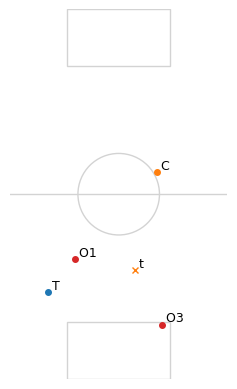

In [3]:
demo1_1 = Scene([
    Coach('C').at(3.5, 2),
    Teammate('T').at(-6.5, -9),
    Opponent('O1').at(-4, -6),
    Opponent('O3').at(4, -12),
    Target('t').at(1.5, -7)
])

plotField(demo1_1, axis=False)

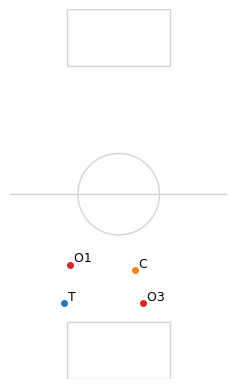

In [4]:
demo1_2 = Scene([
    Coach('C').at(1.5, -7),
    Teammate('T').at(-5, -10),
    Opponent('O1').at(-4.5, -6.5),
    Opponent('O3').at(2.2, -10)
])

plotField(demo1_2, axis=False)

In [5]:
narration1 = "(a) Drop down deeper to create an angle of pass between you and your teammate (b) and pass the ball."

#### Demo 2

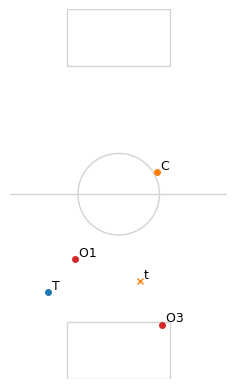

In [6]:
demo2_1 = Scene([
    Coach('C').at(3.5, 2),
    Teammate('T').at(-6.5, -9),
    Opponent('O1').at(-4, -6),
    Opponent('O3').at(4, -12),
    Target('t').at(2, -8)
])

plotField(demo2_1, axis=False)

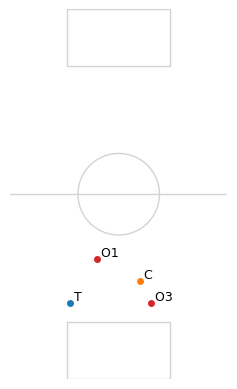

In [7]:
demo2_2 = Scene([
    Coach('C').at(2, -8),
    Teammate('T').at(-4.5, -10),
    Opponent('O1').at(-2, -6),
    Opponent('O3').at(3, -10)
])

plotField(demo2_2, axis=False)

In [8]:
narration2 = "(a) Move ahead and create an angle of pass with your teammate to (b) pass the ball."

In [9]:
narration3 = "(a) Create an angle of pass between you and your teammate."

In [10]:
demoMap = {
    '1': {
        'a': demo1_1,
        'b': demo1_2
    },
    '2': {
        'a': demo2_1,
        'b': demo2_2
    },
    '3': {
        'a': demo1_1,
    },
}

In [11]:
narrations = '\n'.join([f"Demo {i + 1}: {n}" for i, n in enumerate([narration1, narration2, narration3])])
print(narrations)

Demo 1: (a) Drop down deeper to create an angle of pass between you and your teammate (b) and pass the ball.
Demo 2: (a) Move ahead and create an angle of pass with your teammate to (b) pass the ball.
Demo 3: (a) Create an angle of pass between you and your teammate.


In [12]:
from interpretable import Interpretable
from task import Task

tasks = Task.fromInterpretable(Interpretable(language=narrations))

for t in tasks:
    print(str(t))

Task ID: 0
Objective (what): Create an angle of pass between you and your teammate.
Control (how): Drop down deeper or move ahead as necessary to create the angle.
Termination (until): 
Condition (when): 
Task ID: 1
Objective (what): Pass the ball.
Control (how): 
Termination (until): 
Condition (when): 


In [13]:
from action import *

act = Act()
actions = Action.fromTask(tasks, actionsAPI)
act.do(actions)

In [19]:
act.actions

[<api.football.MoveTo at 0x129d28e10>, <api.football.PassTo at 0x129d204d0>]

In [14]:
str(act.actions[1].task)

'Task ID: 1\nObjective (what): Pass the ball.\nControl (how): \nTermination (until): \nCondition (when): '

In [15]:
for a in act.actions:
    a.learn(demoMap)

In [18]:
act.actions[0]

In [16]:
print(act.export())

{
    "actions": [
        {
            "id": "MoveTo",
            "args": {
                "target": {
                    "logic": "A AND (B OR C)",
                    "identifiers": [
                        "A",
                        "B",
                        "C"
                    ],
                    "constraints": [
                        {
                            "id": "HasAngleOfPass",
                            "args": {
                                "ref": "T",
                                "radius": {
                                    "avg": 2.4318418565801534,
                                    "std": 0.1806706174145534
                                }
                            }
                        },
                        {
                            "id": "InZone",
                            "args": {
                                "zone": [
                                    "C2"
                                ]
                  